/var/folders/kr/npf8ybm56gx6gndx2dby4c8r0000gn/T/ipykernel_6256/3798214380.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/nadia.momtaz/Downloads/merged_data2.csv")


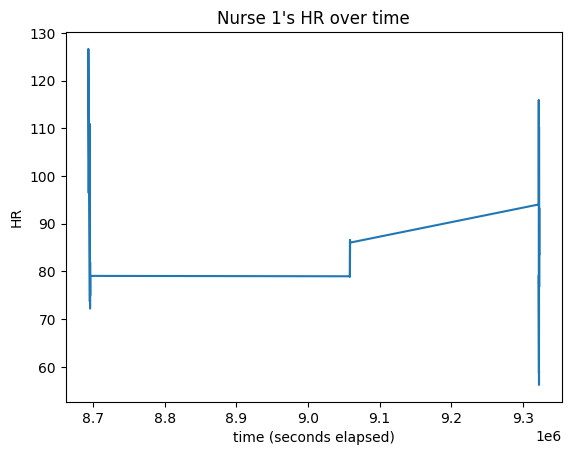

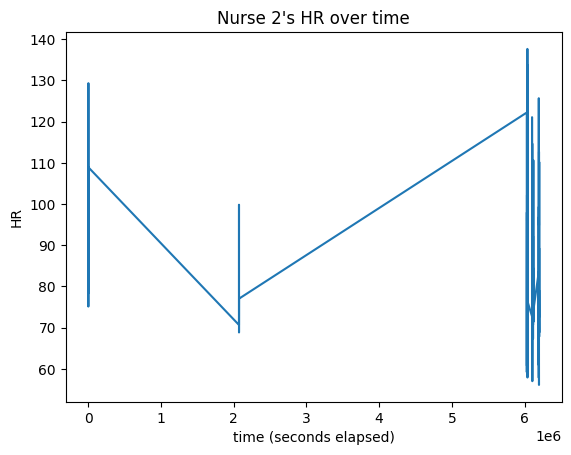

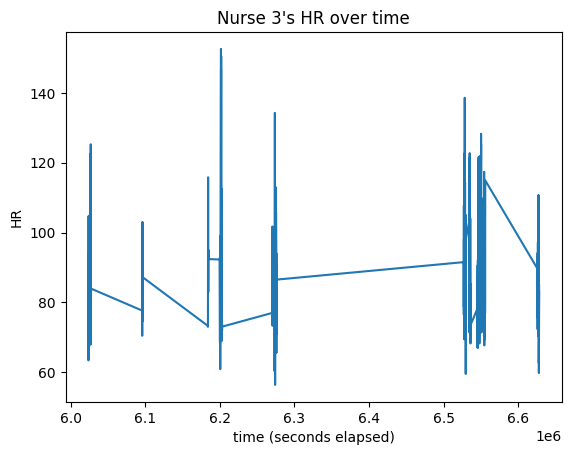

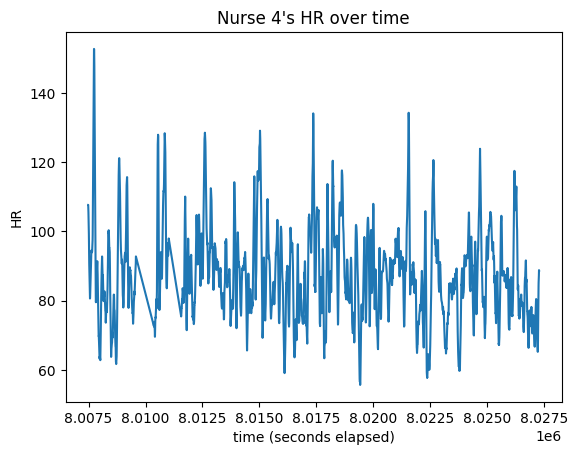

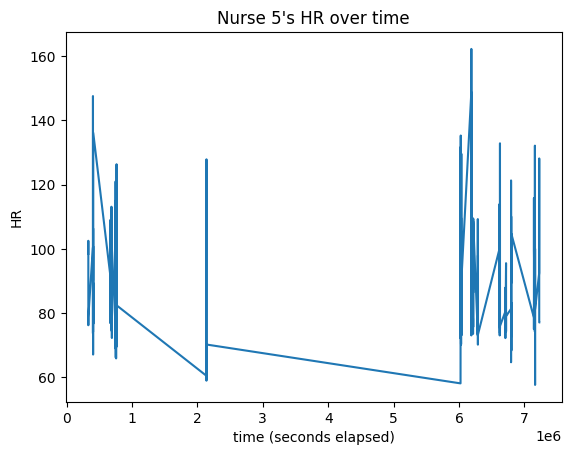

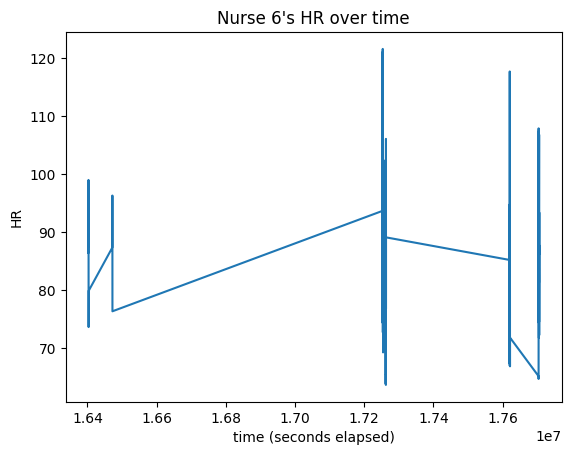

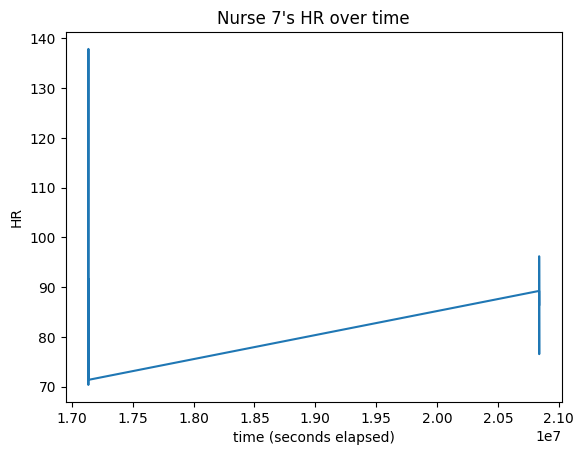

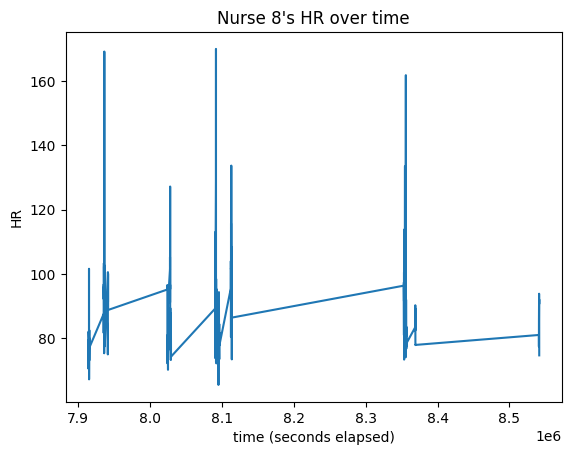

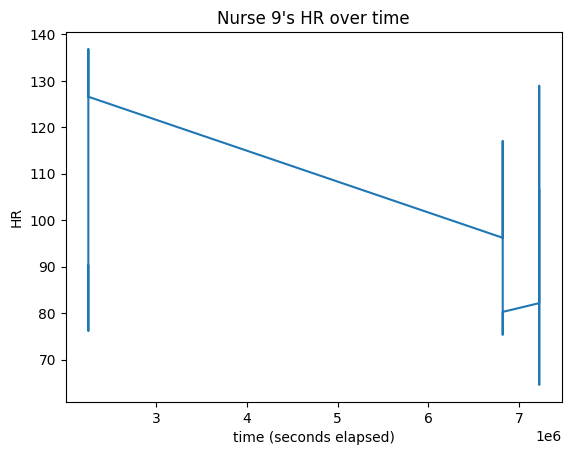

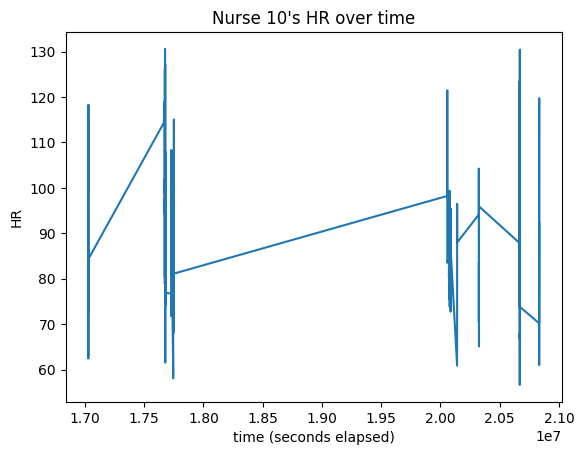

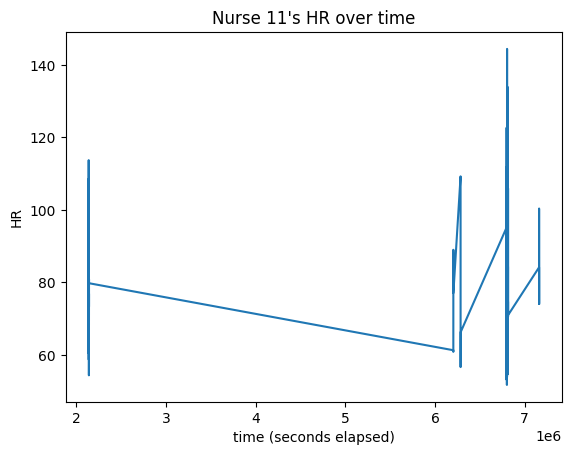

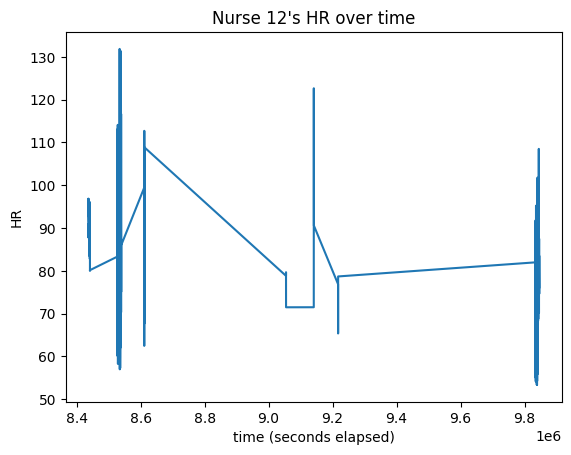

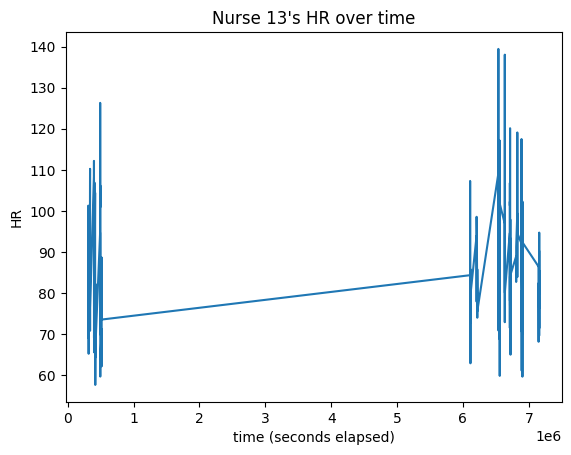

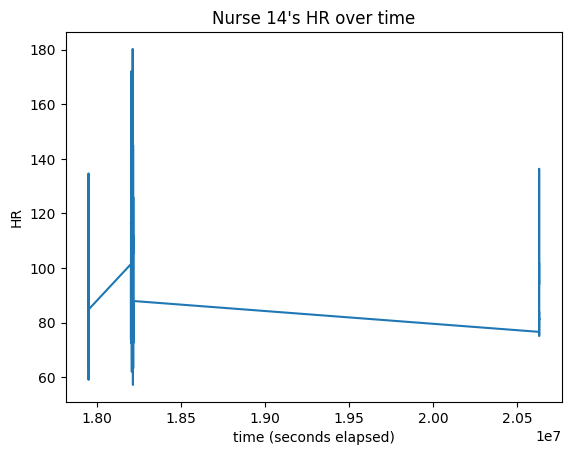

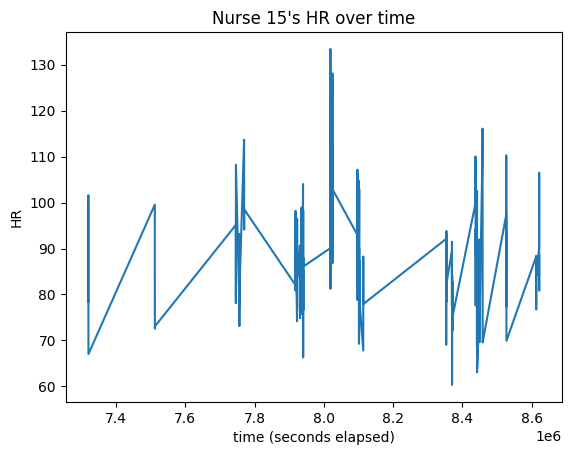

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/Users/nadia.momtaz/Downloads/merged_data2.csv")
df.head()
df.shape
import numpy as np

patients = np.unique(df["id"].astype(str))
df["time"] = pd.to_datetime(df["datetime"])

df["seconds_elapsed"] = (df["time"] - df["time"].min()).dt.total_seconds()
for i in range (len(patients)):
    one_patient = df[df["id"] == patients[i]]
    sample = one_patient.sample(5000, random_state=42).sort_values("seconds_elapsed")
    # sample = one_patient.iloc[420000:]
    plt.plot(sample['seconds_elapsed'], sample['HR'])
    plt.xlabel("time (seconds elapsed)")
    plt.ylabel("HR")
    plt.title(f"Nurse {i+1}'s HR over time")
    plt.show()

In [24]:
df_10sec = df.copy()
df_10sec['time_bin'] = (df_10sec['seconds_elapsed'] // 10).astype(int)

# Explicitly list the columns you want to average
cols_to_avg = ['HR', 'TEMP', 'EDA', 'label']  # adjust to your actual columns

df_averaged = (
    df_10sec
    .groupby(['time_bin', 'id'])[cols_to_avg]
    .mean()
    .reset_index()
)

print(df_averaged.head())

   time_bin  id      HR    TEMP        EDA  label
0         0  5C  82.316  36.500  22.103413    1.0
1         1  5C  81.118  36.499  22.298288    1.0
2         2  5C  80.156  36.495  22.046580    1.0
3         3  5C  79.878  36.497  21.413281    1.0
4         4  5C  79.831  36.488  21.335523    1.0


In [27]:
df_averaged.head()

,time_bin,id,HR,TEMP,EDA,label
0,0,5C,82.316,36.500,22.103413,1.0
1,1,5C,81.118,36.499,22.298288,1.0
2,2,5C,80.156,36.495,22.046580,1.0
3,3,5C,79.878,36.497,21.413281,1.0
4,4,5C,79.831,36.488,21.335523,1.0


In [23]:
df_10sec = df.copy()

# Create 10-second bins
df_10sec['time_bin'] = pd.cut(df_10sec['seconds_elapsed'], bins=np.arange(0, df_10sec['seconds_elapsed'].max() + 10, 10))
df_10sec['id'] = df_10sec['id'].astype('category')

# Group by BOTH time bin and id — keeps different ids separate
df_averaged = df_10sec.groupby(['time_bin', 'id']).mean(numeric_only=True).reset_index()

print(f"Original dataframe shape: {df.shape}")
print(f"Averaged dataframe shape: {df_averaged.shape}")
print(df_averaged.head())

/var/folders/kr/npf8ybm56gx6gndx2dby4c8r0000gn/T/ipykernel_6256/3626196308.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_averaged = df_10sec.groupby(['time_bin', 'id']).mean(numeric_only=True).reset_index()


KeyboardInterrupt: 

In [4]:
df_averaged["time_bin_start"] = df_averaged["time_bin"].apply(lambda x: x.left)

In [25]:
df_averaged.head(10)

,time_bin,id,HR,TEMP,EDA,label
0,0,5C,82.316,36.500,22.103413,1.0
1,1,5C,81.118,36.499,22.298288,1.0
2,2,5C,80.156,36.495,22.046580,1.0
3,3,5C,79.878,36.497,21.413281,1.0
4,4,5C,79.831,36.488,21.335523,1.0
5,5,5C,80.092,36.498,21.313805,1.0
6,6,5C,81.498,36.500,20.635676,1.0
7,7,5C,83.834,36.500,20.074212,1.0
8,8,5C,85.754,36.505,20.276461,1.0
9,9,5C,86.606,36.502,19.973041,1.0


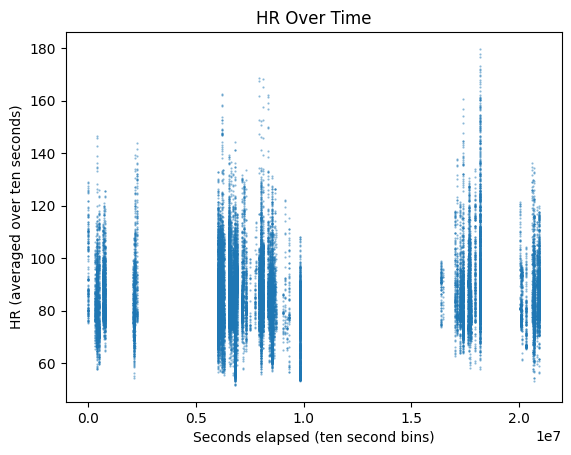

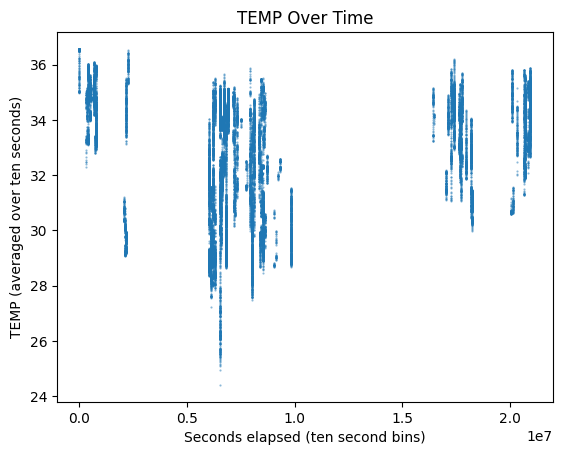

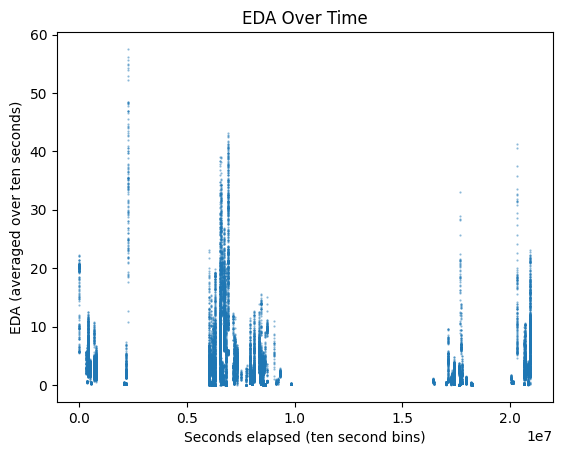

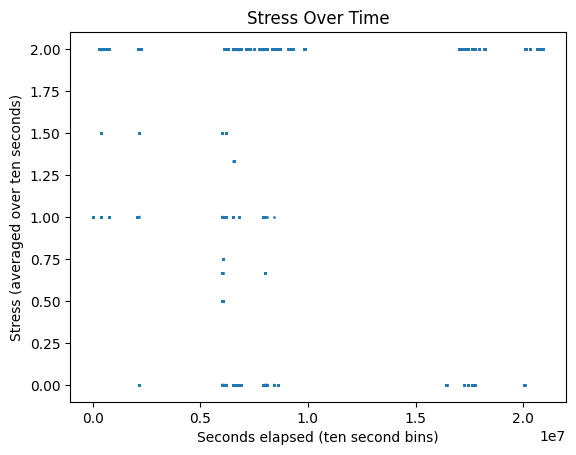

In [11]:
plt.scatter(df_averaged["seconds_elapsed"],df_averaged["HR"], alpha = 0.5, s = 0.3)
plt.xlabel("Seconds elapsed (ten second bins)")
plt.ylabel("HR (averaged over ten seconds)")
plt.title("HR Over Time")
plt.show()


plt.scatter(df_averaged["seconds_elapsed"],df_averaged["TEMP"], alpha = 0.5, s = 0.3)
plt.xlabel("Seconds elapsed (ten second bins)")
plt.ylabel("TEMP (averaged over ten seconds)")
plt.title("TEMP Over Time")
plt.show()



plt.scatter(df_averaged["seconds_elapsed"],df_averaged["EDA"], alpha = 0.5, s = 0.3)
plt.xlabel("Seconds elapsed (ten second bins)")
plt.ylabel("EDA (averaged over ten seconds)")
plt.title("EDA Over Time")
plt.show()

plt.scatter(df_averaged["seconds_elapsed"],df_averaged["label"], alpha = 0.5, s = 0.3)
plt.xlabel("Seconds elapsed (ten second bins)")
plt.ylabel("Stress (averaged over ten seconds)")
plt.title("Stress Over Time")
plt.show()

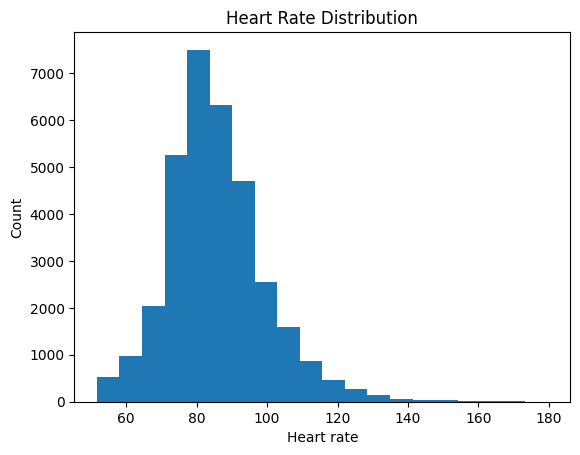

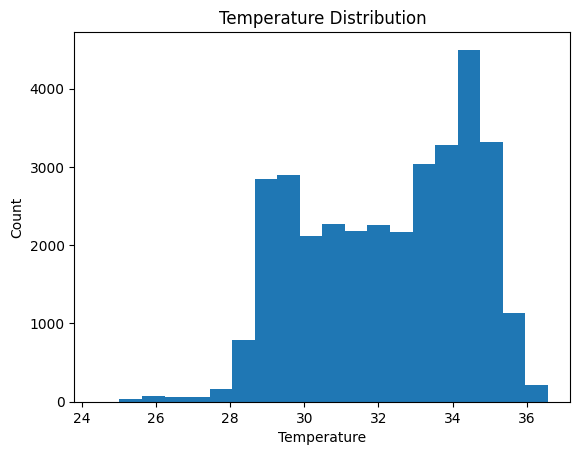

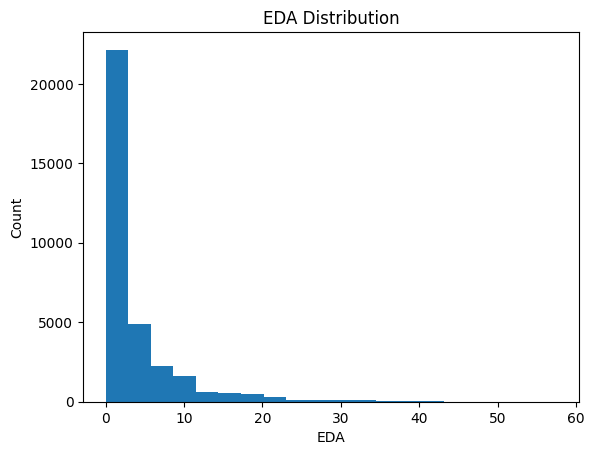

In [14]:
plt.hist(df_averaged["HR"], bins = 20)
plt.xlabel("Heart rate")
plt.ylabel("Count")
plt.title("Heart Rate Distribution")
plt.show()

plt.hist(df_averaged["TEMP"], bins = 20)
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.title("Temperature Distribution")
plt.show()

plt.hist(df_averaged["EDA"], bins = 20)
plt.xlabel("EDA")
plt.ylabel("Count")
plt.title("EDA Distribution")
plt.show()

In [28]:
# split into training and testing data 

data = df_averaged.copy()
data["time_bin"] = data["time_bin"] *10

In [42]:
len(data)

35852

In [ ]:
# SPLIT DATA

train = data[data['time_bin'] <= 20000000]
test = data[data['time_bin'] > 20000000]

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

print("Number of unique IDs in train set:", len(np.unique(train["id"].astype(str))))
print("Number of unique IDs in test set:", len(np.unique(test["id"].astype(str))))

Train shape: (32041, 6)
Test shape: (3811, 6)
Number of unique IDs in train set: 15
Number of unique IDs in test set: 3


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier